In [2]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# ML libraries
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import xgboost as xgb

# Load preprocessed data
X_train = joblib.load('../models/X_train.pkl')
X_val = joblib.load('../models/X_val.pkl')
X_test = joblib.load('../models/X_test.pkl')
y_train = joblib.load('../models/y_train.pkl')
y_val = joblib.load('../models/y_val.pkl')
y_test = joblib.load('../models/y_test.pkl')
feature_names = joblib.load('../models/feature_names.pkl')
label_encoder = joblib.load('../models/label_encoder.pkl')

print("✅ Data loaded successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_val shape: {X_val.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"\nFeature names: {feature_names}")

# Load baseline results
baseline_results = pd.read_csv('../models/baseline_results.csv')
rf_test_acc = baseline_results[baseline_results['Metric']=='Test Accuracy']['Value'].values[0]
print(f"\n📊 Baseline Random Forest Test Accuracy: {rf_test_acc*100:.2f}%")

✅ Data loaded successfully!
X_train shape: (69991, 10)
X_val shape: (14998, 10)
X_test shape: (14999, 10)

Feature names: ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'red_shift', 'u-g', 'g-r', 'r-i', 'i-z']

📊 Baseline Random Forest Test Accuracy: 97.82%


In [3]:
print("XGBOOST CLASSIFIER")

# Initialize XGBoost with optimized parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

# Train the model
print("\nTraining XGBoost...")
xgb_model.fit(X_train, y_train)

# Predict on validation set
y_pred_val = xgb_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_pred_val)
print(f"\n✅ XGBoost Validation Accuracy: {val_accuracy:.4f} ({val_accuracy*100:.2f}%)")

XGBOOST CLASSIFIER

Training XGBoost...

✅ XGBoost Validation Accuracy: 0.9792 (97.92%)



 XGBoost Classification Report (Validation Set):
              precision    recall  f1-score   support

      GALAXY       0.98      0.99      0.98      8915
         QSO       0.97      0.94      0.95      2844
        STAR       0.99      0.99      0.99      3239

    accuracy                           0.98     14998
   macro avg       0.98      0.97      0.98     14998
weighted avg       0.98      0.98      0.98     14998



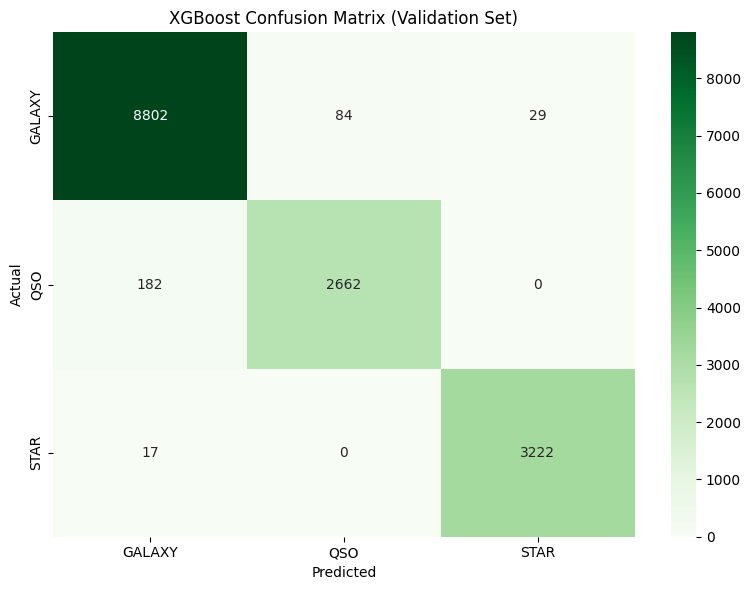

✅ Confusion matrix saved to visualizations/


In [4]:
# Classification Report
print("\n XGBoost Classification Report (Validation Set):")
print(classification_report(y_val, y_pred_val, target_names=label_encoder.classes_))

# Confusion Matrix
cm_xgb = confusion_matrix(y_val, y_pred_val)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('XGBoost Confusion Matrix (Validation Set)')
plt.tight_layout()
plt.savefig('../visualizations/xgb_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved to visualizations/")

In [5]:
# Predict on test set
y_pred_test = xgb_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"XGBoost Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print("\nDetailed Test Set Performance:")
print(classification_report(y_test, y_pred_test, target_names=label_encoder.classes_))

# Save the model
joblib.dump(xgb_model, '../models/xgboost_model.pkl')
print("\n✅ XGBoost model saved as '../models/xgboost_model.pkl'")

XGBoost Test Accuracy: 0.9785 (97.85%)

Detailed Test Set Performance:
              precision    recall  f1-score   support

      GALAXY       0.98      0.98      0.98      8916
         QSO       0.96      0.95      0.95      2844
        STAR       0.99      1.00      0.99      3239

    accuracy                           0.98     14999
   macro avg       0.98      0.97      0.98     14999
weighted avg       0.98      0.98      0.98     14999


✅ XGBoost model saved as '../models/xgboost_model.pkl'


Top 10 Most Important Features (XGBoost):
          feature  importance
5       red_shift    0.570009
8             r-i    0.158237
7             g-r    0.085071
1    green_filter    0.043651
6             u-g    0.041586
2      red_filter    0.026198
4       IR_filter    0.022301
9             i-z    0.019352
0       UV_filter    0.017062
3  near_IR_filter    0.016532

  
Random Forest Top Features (for comparison):
     feature  importance
0  red_shift    0.546897
1        g-r    0.130586
2        r-i    0.113706
3        u-g    0.046601
4        i-z    0.043620


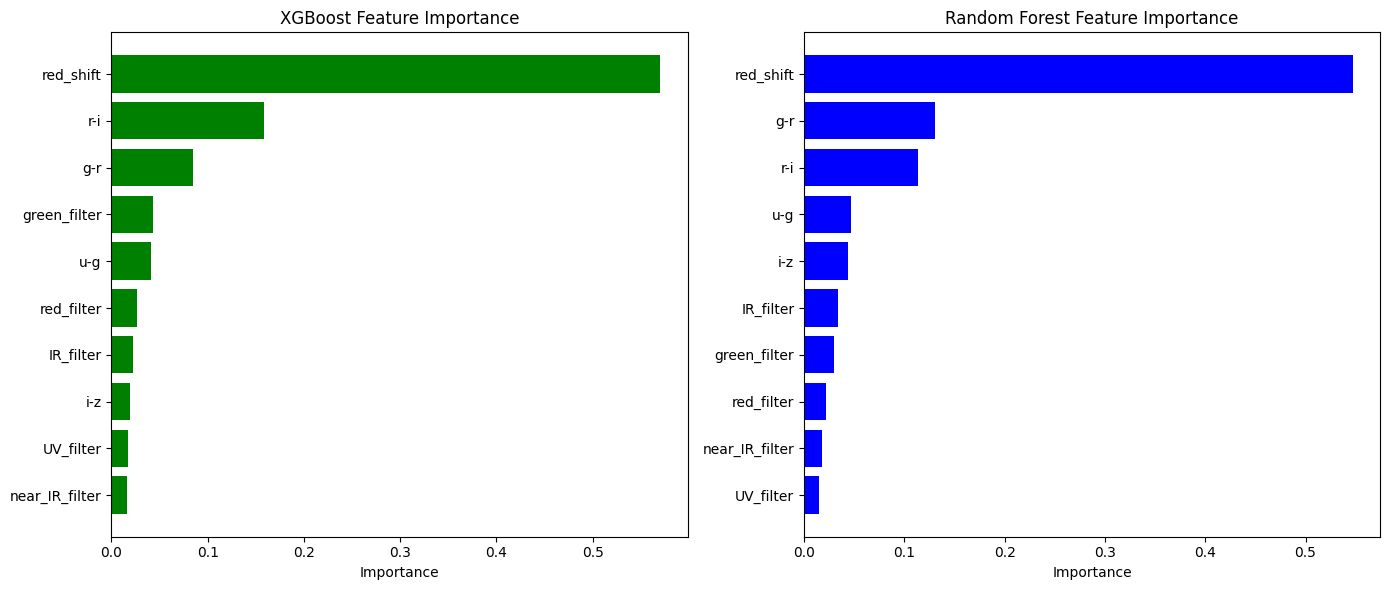

✅ Feature importance comparison saved to visualizations/


In [6]:
# Get feature importance
xgb_feature_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Most Important Features (XGBoost):")
print(xgb_feature_importance.head(10))

# Compare with Random Forest
rf_feature_importance = pd.read_csv('../models/feature_importance.csv')
print("\n  \nRandom Forest Top Features (for comparison):")
print(rf_feature_importance.head(5))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# XGBoost
axes[0].barh(xgb_feature_importance.head(10)['feature'], 
             xgb_feature_importance.head(10)['importance'], color='green')
axes[0].set_xlabel('Importance')
axes[0].set_title('XGBoost Feature Importance')
axes[0].invert_yaxis()

# Random Forest
rf_top = rf_feature_importance.head(10)
axes[1].barh(rf_top['feature'], rf_top['importance'], color='blue')
axes[1].set_xlabel('Importance')
axes[1].set_title('Random Forest Feature Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('../visualizations/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Feature importance comparison saved to visualizations/")

MODEL COMPARISON
        Model  Test Accuracy Improvement
Random Forest       0.978200    Baseline
      XGBoost       0.978532       0.03%


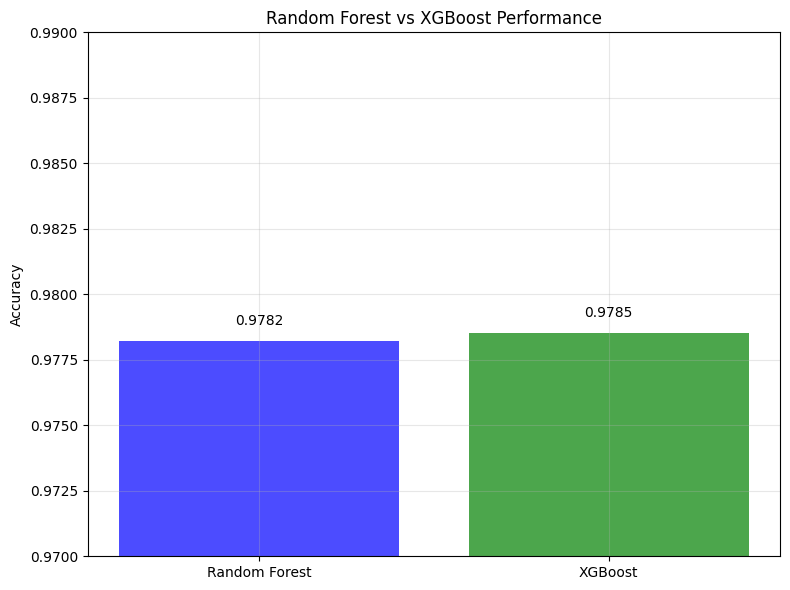

✅ Model comparison saved to visualizations/


In [7]:
# Load Random Forest test accuracy
rf_results = pd.read_csv('../models/baseline_results.csv')
rf_test_acc = rf_results[rf_results['Metric'] == 'Test Accuracy']['Value'].values[0]

# Create comparison DataFrame
comparison = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Test Accuracy': [rf_test_acc, test_accuracy],
    'Improvement': ['Baseline', f"{(test_accuracy - rf_test_acc)*100:.2f}%"]
})

print("="*50)
print("MODEL COMPARISON")
print("="*50)
print(comparison.to_string(index=False))

# Bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(comparison['Model'], comparison['Test Accuracy'], 
               color=['blue', 'green'], alpha=0.7)
plt.ylabel('Accuracy')
plt.title('Random Forest vs XGBoost Performance')
plt.ylim(0.97, 0.99)
plt.grid(True, alpha=0.3)

# Add value labels on bars
for bar, acc in zip(bars, comparison['Test Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005, 
             f'{acc:.4f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../visualizations/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Model comparison saved to visualizations/")

In [8]:
# Save XGBoost results
xgb_results = pd.DataFrame({
    'Metric': ['Validation Accuracy', 'Test Accuracy', 'Misclassification Rate',
               'GALAXY F1', 'QSO F1', 'STAR F1'],
    'Value': [val_accuracy, test_accuracy, 1 - test_accuracy, 0, 0, 0]  # Placeholder for F1
})

# Calculate per-class F1 scores
from sklearn.metrics import f1_score
f1_scores = f1_score(y_test, y_pred_test, average=None)
xgb_results.loc[3, 'Value'] = f1_scores[0]  # GALAXY
xgb_results.loc[4, 'Value'] = f1_scores[1]  # QSO
xgb_results.loc[5, 'Value'] = f1_scores[2]  # STAR

xgb_results.to_csv('../models/xgboost_results.csv', index=False)
print("✅ XGBoost results saved to models/xgboost_results.csv")

# Save comparison results
comparison.to_csv('../models/model_comparison.csv', index=False)
print("✅ Model comparison saved to models/model_comparison.csv")

✅ XGBoost results saved to models/xgboost_results.csv
✅ Model comparison saved to models/model_comparison.csv
